# 📄 Early Dysgraphia Screening from Handwriting
### A CRISP-DM Capstone Project

This notebook follows the **CRISP-DM methodology** (Cross-Industry Standard Process for Data Mining):

1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Modeling
5. Evaluation
6. Deployment

**Dataset:** Potential Dysgraphia Handwriting Dataset of School-Age Children (Malaysian Dyslexia Association, PDM)


---
## Step 1: Business Understanding

### Overview
Dysgraphia is a writing-specific learning difficulty where a child's handwriting fails to match what is
expected for their age and cognitive level — showing up as poor letter formation, inconsistent spacing
and sizing, irregular pressure, and difficulty maintaining a straight baseline. It is one of the most
common, and most commonly missed, learning difficulties in primary-school-aged children. In
under-resourced schools — which describes most public primary schools in Kenya — there is no
educational psychologist on staff, so the referral never happens. The child is mislabeled as slow,
careless, or lazy, and the mislabeling does its own damage on top of the learning difficulty.

### Problem Statement
Teachers and parents currently have no quick, low-cost way to check whether a child's handwriting shows
dysgraphia-related patterns before committing to a slow, expensive specialist referral. The signs are
visible in the child's handwriting from the very first pages they write, yet detection depends entirely
on someone noticing over weeks or months. The children most affected are from lower-income households —
exactly where the referral pathway is weakest.

### Proposed Solution
A deep learning screening aid that takes a photo or scan of a handwriting sample and classifies it into
**Potential Dysgraphia** or **Low Potential Dysgraphia**, with a confidence score and interpretable
indicators (spacing consistency, baseline deviation). It is strictly a **screening and referral aid —
not a clinical diagnosis.** A positive flag always means *"worth getting checked by a professional."*

### Business Objectives
1. Build a binary CNN classifier matching the clinical labeling scheme of the dataset's professional assessors.
2. Use transfer learning from a pretrained image backbone to detect visual patterns: irregular letter
   formation, inconsistent sizing/spacing, uneven pressure, shaky baseline alignment.
3. Pair the CNN output with interpretable, statistically grounded indicators so a teacher or parent gets
   a *reason*, not just a label.
4. Prioritize **Recall on the Potential Dysgraphia class** — missing an at-risk child is the real cost
   this tool exists to avoid.
5. Wrap the model in a simple web interface as an awareness and referral aid.

### Target Users / Stakeholders
Children with undiagnosed dysgraphia; parents; teachers and school counsellors; under-resourced schools;
educational psychologists and assessment centres; inclusive-education NGOs.

### Success Criteria
- **Recall on the Potential Dysgraphia class** (protected above all others)
- Acceptable precision to avoid needless parent worry
- Strong F1-score and ROC-AUC
- Interpretability verified via Grad-CAM — confirming the model keys on letter shape, spacing, and
  pressure, not paper texture or scan artifacts


---
## Setup

Import libraries and set a fixed random seed everywhere for reproducibility.


In [4]:
import os
import glob
import random
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, f1_score
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
import zipfile

# ---- Paths ----
# Point this at the folder that directly contains the two class subfolders:
#   <DATA_DIR>/Potential Dysgraphia/*.jpg
#   <DATA_DIR>/Low Potential Dysgraphia/*.jpg

OUTER_ZIP = Path("Potential Dysgraphia Handwriting Dataset of School-Age Children.zip")
INNER_DIR = Path("Potential Dysgraphia Handwriting Dataset of School-Age Children")
INNER_ZIP = INNER_DIR / "DATASET DYSGRAPHIA HANDWRITING.zip"
DATA_DIR = Path("data/DATASET DYSGRAPHIA HANDWRITING")

CLASS_PD  = "Potential Dysgraphia"       # positive class (label = 1)
CLASS_LPD = "Low Potential Dysgraphia"   # negative class (label = 0)

IMG_SIZE = (224, 224)
BATCH_SIZE = 16

# Step 1: unzip the outer zip (if not already extracted)
if not INNER_DIR.exists():
    assert OUTER_ZIP.exists(), f"Outer zip not found: {OUTER_ZIP.resolve()}"
    print(f"Unzipping {OUTER_ZIP} ...")
    with zipfile.ZipFile(OUTER_ZIP, "r") as zf:
        zf.extractall(".")
else:
    print(f"Outer zip already extracted to: {INNER_DIR}")

# Step 2: unzip the inner dataset zip into data/ (if not already extracted)
if not DATA_DIR.exists():
    assert INNER_ZIP.exists(), f"Inner zip not found: {INNER_ZIP.resolve()}"
    print(f"Unzipping {INNER_ZIP} ...")
    with zipfile.ZipFile(INNER_ZIP, "r") as zf:
        zf.extractall("data")
else:
    print(f"Inner zip already extracted to: {DATA_DIR}")

assert DATA_DIR.exists(), f"DATA_DIR not found: {DATA_DIR.resolve()} — update the path above."
print("Data directory:", DATA_DIR.resolve())

Outer zip already extracted to: Potential Dysgraphia Handwriting Dataset of School-Age Children
Inner zip already extracted to: data/DATASET DYSGRAPHIA HANDWRITING
Data directory: /content/data/DATASET DYSGRAPHIA HANDWRITING


---
## Step 2: Data Understanding

### Data Sources
Primary — The **Potential Dysgraphia Handwriting Dataset**, collected by the Malaysian Dyslexia
Association (PDM) from schoolchildren, each sample clinically assessed and sorted into two classes.
Already downloaded and organized locally into two folders: Potential Dysgraphia (PD) and Low Potential
Dysgraphia (LPD).

### Data Characteristics
- Full handwriting passage images (JPG), pre-binarized (white text on black background).
- Highly variable dimensions (e.g., 506×55 px up to 1318×365 px) — resizing with aspect-ratio padding is mandatory.
- Content is in **Malay**. This does not limit applicability: dysgraphia is a **motor/visual** disorder,
  not a language-comprehension one. The model learns *how* someone writes (formation, spacing, pressure,
  slant), not *what* they wrote. These mechanics appear identically across Latin-alphabet languages,
  including English and Swahili.
- Small sample size (~200 images total; PD folder currently shows 114 items) — demanding augmentation
  and transfer learning.

### Data Quality Checks
1. Audit exact image counts per class and compute the balance ratio.
2. Load every file in a try/except loop to detect and quarantine corrupted images.
3. Log dimension and aspect-ratio distributions.
4. Visual inspection of sample grids per class to confirm labels match visible traits
   (PD = irregular, floating, inconsistent; LPD = neat, aligned).
5. Pixel-intensity histograms to confirm consistent binarization.
6. Six EDA visualizations: class balance bar chart, size distribution, sample grids for both classes,
   aspect-ratio histogram, intensity histogram.


### 2.1 Audit exact image counts per class and compute balance ratio

In [6]:
def list_images(folder):
    exts = ("*.jpg", "*.jpeg", "*.JPG", "*.JPEG", "*.png", "*.PNG")
    files = []
    for e in exts:
        files.extend(glob.glob(str(folder / e)))
    return sorted(files)

pd_files  = list_images(DATA_DIR / CLASS_PD)
lpd_files = list_images(DATA_DIR / CLASS_LPD)

n_pd, n_lpd = len(pd_files), len(lpd_files)
total = n_pd + n_lpd
balance_ratio = n_pd / n_lpd if n_lpd else float('nan')

print(f"Potential Dysgraphia (PD):      {n_pd} images")
print(f"Low Potential Dysgraphia (LPD): {n_lpd} images")
print(f"Total:                          {total} images")
print(f"Balance ratio (PD / LPD):       {balance_ratio:.2f}")


Potential Dysgraphia (PD):      114 images
Low Potential Dysgraphia (LPD): 135 images
Total:                          249 images
Balance ratio (PD / LPD):       0.84


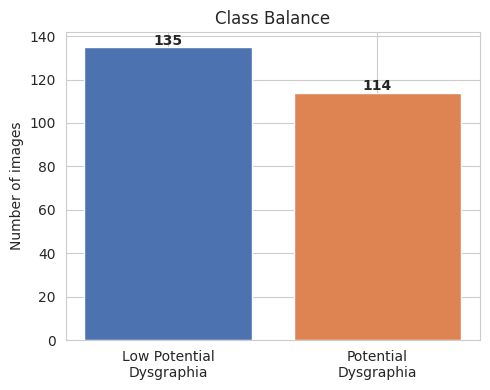

In [7]:
# Class balance bar chart (EDA visualization 1/6)
fig, ax = plt.subplots(figsize=(5, 4))
counts = [n_lpd, n_pd]
labels = ["Low Potential\nDysgraphia", "Potential\nDysgraphia"]
bars = ax.bar(labels, counts, color=["#4C72B0", "#DD8452"])
for bar, c in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, c + 1, str(c), ha="center", fontweight="bold")
ax.set_ylabel("Number of images")
ax.set_title("Class Balance")
plt.tight_layout()
plt.show()


### 2.2 Load every file in a try/except loop — detect and quarantine corrupted images

In [8]:
def audit_images(files):
    """Attempt to open + verify every image. Returns (good_records, corrupted_paths)."""
    good = []
    corrupted = []
    for f in files:
        try:
            with Image.open(f) as im:
                im.verify()  # cheap corruption check
            with Image.open(f) as im:  # re-open: verify() invalidates the file handle
                w, h = im.size
                mode = im.mode
            good.append({"path": f, "width": w, "height": h, "mode": mode,
                         "aspect_ratio": w / h})
        except Exception as e:
            corrupted.append((f, str(e)))
    return good, corrupted

pd_records,  pd_corrupted  = audit_images(pd_files)
lpd_records, lpd_corrupted = audit_images(lpd_files)

print(f"PD:  {len(pd_records)} OK, {len(pd_corrupted)} corrupted")
print(f"LPD: {len(lpd_records)} OK, {len(lpd_corrupted)} corrupted")

if pd_corrupted or lpd_corrupted:
    print("\nQuarantined files:")
    for f, err in pd_corrupted + lpd_corrupted:
        print(f"  {f}: {err}")
else:
    print("\nNo corrupted images detected — no quarantine needed.")


PD:  114 OK, 0 corrupted
LPD: 135 OK, 0 corrupted

No corrupted images detected — no quarantine needed.


In [9]:
# Build a combined DataFrame with a label column: 1 = Potential Dysgraphia, 0 = Low Potential Dysgraphia
for r in pd_records:
    r["label"] = 1
    r["class_name"] = CLASS_PD
for r in lpd_records:
    r["label"] = 0
    r["class_name"] = CLASS_LPD

df = pd.DataFrame(pd_records + lpd_records)
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)  # shuffle
df.head()


,path,width,height,mode,aspect_ratio,label,class_name
0,data/DATASET DYSGRAPHIA HANDWRITING/Low Potent...,696,99,L,7.030303,0,Low Potential Dysgraphia
1,data/DATASET DYSGRAPHIA HANDWRITING/Potential ...,1277,210,L,6.080952,1,Potential Dysgraphia
2,data/DATASET DYSGRAPHIA HANDWRITING/Potential ...,1209,281,L,4.302491,1,Potential Dysgraphia
3,data/DATASET DYSGRAPHIA HANDWRITING/Potential ...,1277,164,L,7.786585,1,Potential Dysgraphia
4,data/DATASET DYSGRAPHIA HANDWRITING/Potential ...,1218,165,L,7.381818,1,Potential Dysgraphia


### 2.3 Dimension and aspect-ratio distributions

In [10]:
print(df.groupby("class_name")[["width", "height", "aspect_ratio"]].describe().T)


class_name          Low Potential Dysgraphia  Potential Dysgraphia
width        count                135.000000            114.000000
             mean                1020.222222           1173.912281
             std                  275.238476            168.951664
             min                  396.000000            700.000000
             25%                  723.000000           1125.250000
             50%                 1157.000000           1231.000000
             75%                 1250.000000           1271.250000
             max                 1377.000000           1434.000000
height       count                135.000000            114.000000
             mean                 156.022222            195.157895
             std                   69.349264             84.316469
             min                   55.000000             77.000000
             25%                   98.000000            123.000000
             50%                  159.000000            177.50

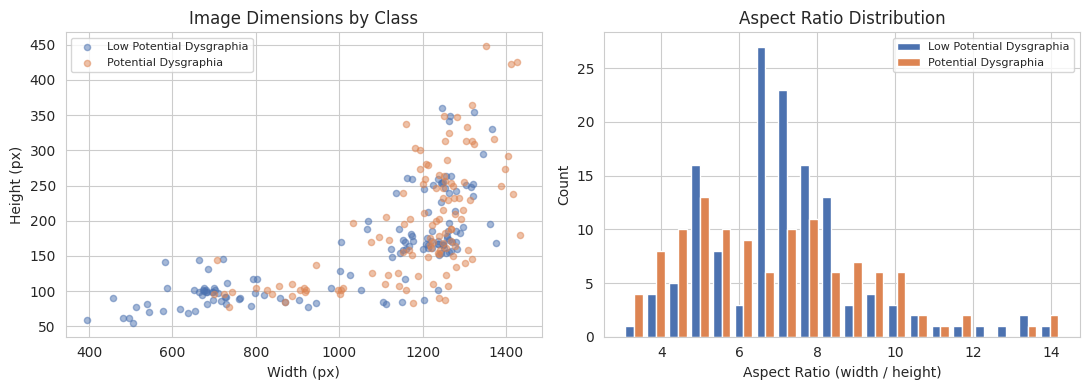

Width range:  396 – 1434 px
Height range: 55 – 448 px
=> Highly variable dimensions confirmed. Aspect-ratio-preserving padding is mandatory at the resizing step (Step 3) to avoid distorting letter shapes and baseline angles.


In [11]:
# Size distribution (EDA visualization 2/6)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for cls, color in zip([CLASS_LPD, CLASS_PD], ["#4C72B0", "#DD8452"]):
    sub = df[df["class_name"] == cls]
    axes[0].scatter(sub["width"], sub["height"], alpha=0.5, label=cls, color=color, s=20)

axes[0].set_xlabel("Width (px)")
axes[0].set_ylabel("Height (px)")
axes[0].set_title("Image Dimensions by Class")
axes[0].legend(fontsize=8)

axes[1].hist([df[df.class_name == CLASS_LPD]["aspect_ratio"],
              df[df.class_name == CLASS_PD]["aspect_ratio"]],
             bins=20, label=[CLASS_LPD, CLASS_PD], color=["#4C72B0", "#DD8452"])
axes[1].set_xlabel("Aspect Ratio (width / height)")
axes[1].set_ylabel("Count")
axes[1].set_title("Aspect Ratio Distribution")   # EDA visualization 4/6
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"Width range:  {df.width.min()} – {df.width.max()} px")
print(f"Height range: {df.height.min()} – {df.height.max()} px")
print("=> Highly variable dimensions confirmed. Aspect-ratio-preserving padding is mandatory "
      "at the resizing step (Step 3) to avoid distorting letter shapes and baseline angles.")


### 2.4 Visual inspection: sample grids per class

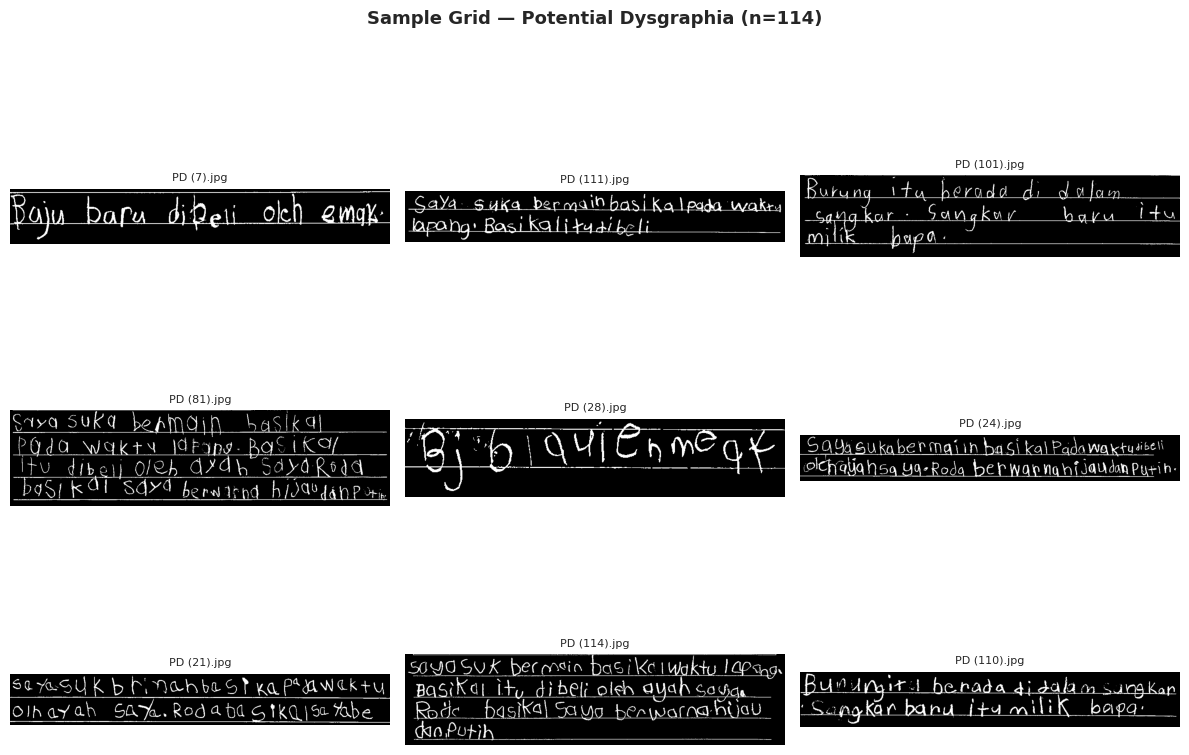

In [12]:
def show_sample_grid(files, title, n=9, cmap="gray"):
    n_cols = 3
    n_rows = int(np.ceil(n / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 3 * n_rows))
    sample = random.sample(files, min(n, len(files)))
    for ax, f in zip(axes.flatten(), sample):
        img = Image.open(f)
        ax.imshow(img, cmap=cmap)
        ax.set_title(Path(f).name, fontsize=8)
        ax.axis("off")
    for ax in axes.flatten()[len(sample):]:
        ax.axis("off")
    fig.suptitle(title, fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

# EDA visualization 3/6 (a): Potential Dysgraphia samples — expect irregular, floating, inconsistent letters
show_sample_grid(pd_files, f"Sample Grid — {CLASS_PD} (n={n_pd})")


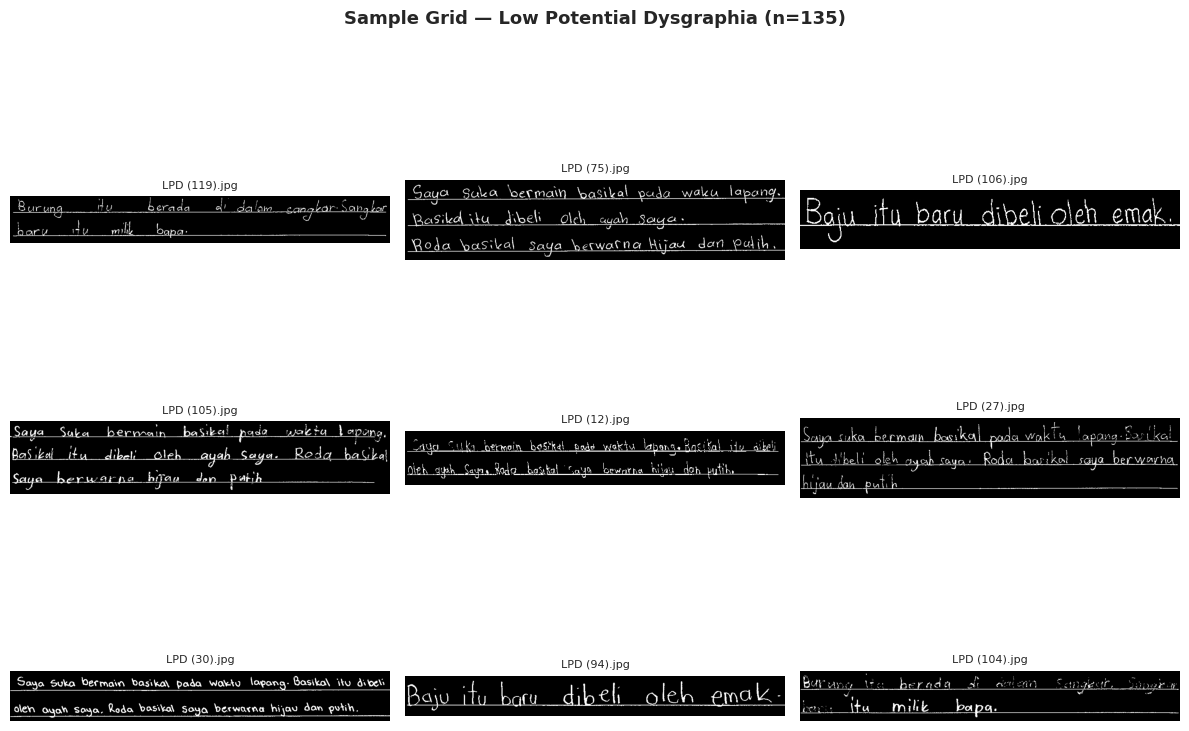

Visual check: PD samples should show irregular letter formation, inconsistent spacing/sizing, and baseline drift. LPD samples should show neat, consistently sized, well-aligned handwriting. If the visible traits don't match the folder labels, flag for re-review before modeling.


In [13]:
# EDA visualization 3/6 (b): Low Potential Dysgraphia samples — expect neat, aligned handwriting
show_sample_grid(lpd_files, f"Sample Grid — {CLASS_LPD} (n={n_lpd})")

print("Visual check: PD samples should show irregular letter formation, inconsistent spacing/sizing, "
      "and baseline drift. LPD samples should show neat, consistently sized, well-aligned handwriting. "
      "If the visible traits don't match the folder labels, flag for re-review before modeling.")


### 2.5 Pixel-intensity histograms — confirm consistent binarization

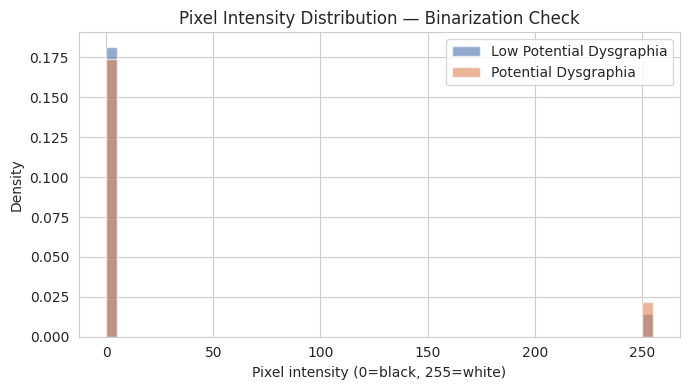

Expect a strongly bimodal distribution clustered near 0 and 255 for both classes, confirming images are pre-binarized (white text on black background) with no systematic exposure/contrast difference between classes that could leak into the model as a spurious signal.


In [14]:
# EDA visualization 5/6: pixel-intensity histograms per class
def sample_intensities(files, n=40):
    vals = []
    for f in random.sample(files, min(n, len(files))):
        arr = np.array(Image.open(f).convert("L"))
        vals.append(arr.flatten())
    return np.concatenate(vals)

pd_intensities  = sample_intensities(pd_files)
lpd_intensities = sample_intensities(lpd_files)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(lpd_intensities, bins=50, alpha=0.6, label=CLASS_LPD, color="#4C72B0", density=True)
ax.hist(pd_intensities,  bins=50, alpha=0.6, label=CLASS_PD,  color="#DD8452", density=True)
ax.set_xlabel("Pixel intensity (0=black, 255=white)")
ax.set_ylabel("Density")
ax.set_title("Pixel Intensity Distribution — Binarization Check")
ax.legend()
plt.tight_layout()
plt.show()

print("Expect a strongly bimodal distribution clustered near 0 and 255 for both classes, confirming "
      "images are pre-binarized (white text on black background) with no systematic exposure/contrast "
      "difference between classes that could leak into the model as a spurious signal.")


### Data Understanding — Summary

Six EDA visualizations produced: class balance bar chart, dimension scatter, sample grids (both
classes), aspect-ratio histogram, and pixel-intensity histogram. Findings so far feed directly into
Step 3 (aspect-ratio-preserving resize, grayscale normalization, stratified split, class-weighted
training if imbalance is confirmed).


---
## Step 3: Data Preparation

i. **Loading:** Read directly from the two class folders (folder name = label), with a fixed seed for reproducibility.

ii. **Grayscale & Normalization:** Convert to single channel; scale pixel values to [0, 1] by dividing by 255.

iii. **Standardization:** Resize all images to a fixed canvas (224×224) using **aspect-ratio-preserving
padding** to avoid distorting letter shapes and baseline angles.

iv. **Splitting:** Stratified 70% train / 15% validation / 15% test, ensuring both classes are
proportionally represented in every split.

v. **Augmentation (training only):** Rotation (±10°), width/height shifts, zoom, and slight shear —
simulating real-world smartphone capture variations.

vi. **Imbalance Handling:** Compute class weights from the audit counts and pass them to training;
apply heavier augmentation to the minority class if the audit reveals imbalance.

vii. **Deliverable:** A reproducible pipeline script + a dataset audit report (counts, sizes, balance,
corrupted-file log).


### 3.1 Stratified 70/15/15 split

In [15]:
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df["label"], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label"], random_state=SEED
)

print(f"Train: {len(train_df)}  (PD={sum(train_df.label==1)}, LPD={sum(train_df.label==0)})")
print(f"Val:   {len(val_df)}  (PD={sum(val_df.label==1)}, LPD={sum(val_df.label==0)})")
print(f"Test:  {len(test_df)}  (PD={sum(test_df.label==1)}, LPD={sum(test_df.label==0)})")

for name, split in [("train", train_df), ("val", val_df), ("test", test_df)]:
    ratio = split["label"].mean()
    print(f"{name}: {ratio:.3f} proportion Potential Dysgraphia")


Train: 174  (PD=80, LPD=94)
Val:   37  (PD=17, LPD=20)
Test:  38  (PD=17, LPD=21)
train: 0.460 proportion Potential Dysgraphia
val: 0.459 proportion Potential Dysgraphia
test: 0.447 proportion Potential Dysgraphia


### 3.2 Aspect-ratio-preserving resize + grayscale normalization

In [16]:
def load_and_preprocess(path, img_size=IMG_SIZE):
    """Grayscale, normalize to [0,1], resize with aspect-ratio-preserving padding to img_size."""
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=1, expand_animations=False)  # grayscale, single channel
    img = tf.image.convert_image_dtype(img, tf.float32)                # scales to [0, 1]
    img = tf.image.resize_with_pad(img, img_size[0], img_size[1])      # preserves aspect ratio
    return img

def make_dataset(dataframe, img_size=IMG_SIZE, batch_size=BATCH_SIZE,
                  augment=False, shuffle=False):
    paths  = dataframe["path"].values
    labels = dataframe["label"].values.astype("float32")

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=SEED, reshuffle_each_iteration=True)

    def _load(path, label):
        img = load_and_preprocess(path, img_size)
        return img, label

    ds = ds.map(_load, num_parallel_calls=tf.data.AUTOTUNE)

    if augment:
        ds = ds.map(augment_image, num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


### 3.3 Augmentation (training split only)

In [17]:
# Rotation (+-10deg), width/height shifts, zoom, slight shear -- simulating smartphone capture variation.
augmenter = keras.Sequential([
    layers.RandomRotation(10 / 360),          # +-10 degrees
    layers.RandomTranslation(0.05, 0.05),     # width/height shift
    layers.RandomZoom(0.1),
], name="augmentation")

def augment_image(img, label):
    img = augmenter(img, training=True)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, label


### 3.4 Class weights for imbalance handling

In [18]:
class_weights_arr = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=train_df["label"].values
)
class_weight = {0: class_weights_arr[0], 1: class_weights_arr[1]}
print("Class weights:", class_weight)
print(f"Imbalance ratio in training set: {sum(train_df.label==0)}:{sum(train_df.label==1)} (LPD:PD)")


Class weights: {0: np.float64(0.925531914893617), 1: np.float64(1.0875)}
Imbalance ratio in training set: 94:80 (LPD:PD)


In [19]:
train_ds = make_dataset(train_df, augment=True, shuffle=True)
val_ds   = make_dataset(val_df,   augment=False, shuffle=False)
test_ds  = make_dataset(test_df,  augment=False, shuffle=False)

# Sanity check: pull one batch and confirm shape/range
for imgs, lbls in train_ds.take(1):
    print("Batch image shape:", imgs.shape)
    print("Pixel value range:", float(tf.reduce_min(imgs)), "-", float(tf.reduce_max(imgs)))
    print("Batch labels:", lbls.numpy())


Batch image shape: (16, 224, 224, 1)
Pixel value range: 0.0 - 0.9662286043167114
Batch labels: [0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 1. 0. 1. 1. 1.]


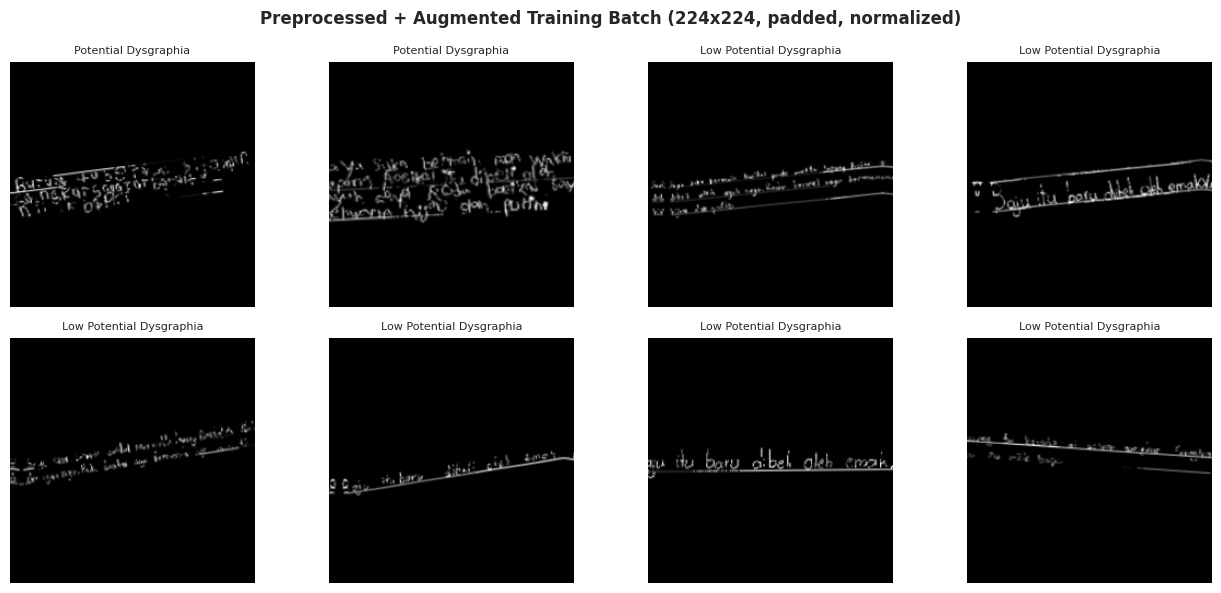

In [20]:
# Visual sanity check of the preprocessing + augmentation pipeline
fig, axes = plt.subplots(2, 4, figsize=(13, 6))
for imgs, lbls in train_ds.take(1):
    for i, ax in enumerate(axes.flatten()):
        if i >= len(imgs):
            ax.axis("off")
            continue
        ax.imshow(imgs[i].numpy().squeeze(), cmap="gray")
        cls = CLASS_PD if lbls[i] == 1 else CLASS_LPD
        ax.set_title(cls, fontsize=8)
        ax.axis("off")
plt.suptitle("Preprocessed + Augmented Training Batch (224x224, padded, normalized)", fontweight="bold")
plt.tight_layout()
plt.show()


### Data Preparation — Deliverable

The cells above constitute the reproducible pipeline (fixed-seed loading → grayscale/normalize →
aspect-ratio-preserving resize → stratified split → augmentation → class weighting). The dataset audit
report is the combination of the Step 2 counts/balance-ratio output, the corrupted-file log, and the
dimension/aspect-ratio distributions above.


---
## Step 4: Modeling

i. **Baseline Model:** A simple custom CNN (3 convolutional blocks) to establish a performance floor.

ii. **Primary Model:** Transfer learning — **MobileNetV2** pretrained on ImageNet (grayscale repeated to
3 channels), base frozen, topped with GlobalAveragePooling → Dense(128, ReLU) → Dropout(0.5) →
Dense(1, Sigmoid). Fine-tune the top base layers at a low learning rate after initial convergence.

iii. **Training Configuration:** Binary cross-entropy with class weights; Adam optimizer (lr=1e-4);
callbacks: EarlyStopping (patience 8), ReduceLROnPlateau, ModelCheckpoint saving best validation F1.

iv. **Evaluation Focus:** Recall on the Potential Dysgraphia class (primary), precision, F1-score,
ROC-AUC, and confusion matrix — plain accuracy is explicitly rejected as insufficient.

v. **Interpretability:** Grad-CAM heatmaps to verify the model attends to letter formation, spacing,
and baseline regions — not incidental artifacts.

vi. **Deliverable by end of modeling phase:** Trained model file (.keras), training logs, and a metrics
table comparing baseline vs. transfer model.


### 4.1 Custom metric: F1-score (for ModelCheckpoint + monitoring)

In [21]:
class F1Score(keras.metrics.Metric):
    """Binary F1-score for the positive (Potential Dysgraphia) class."""
    def __init__(self, name="f1_score", thresh=0.5, **kwargs):
        super().__init__(name=name, **kwargs)
        self.thresh = thresh
        self.precision = keras.metrics.Precision(thresholds=thresh)
        self.recall = keras.metrics.Recall(thresholds=thresh)

    def update_state(self, y_true, y_pred, sample_weight=None):
        self.precision.update_state(y_true, y_pred, sample_weight)
        self.recall.update_state(y_true, y_pred, sample_weight)

    def result(self):
        p = self.precision.result()
        r = self.recall.result()
        return 2 * p * r / (p + r + keras.backend.epsilon())

    def reset_state(self):
        self.precision.reset_state()
        self.recall.reset_state()


### 4.2 Baseline Model — simple custom CNN (3 convolutional blocks)

In [22]:
def build_baseline_cnn(input_shape=(224, 224, 1)):
    inputs = keras.Input(shape=input_shape)
    x = inputs

    for filters in (32, 64, 128):  # 3 convolutional blocks
        x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D()(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    return keras.Model(inputs, outputs, name="baseline_cnn")

baseline_model = build_baseline_cnn()
baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        keras.metrics.AUC(name="auc"),
        F1Score(name="f1_score"),
    ],
)
baseline_model.summary()


Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,889 (398.00 KB)

 Trainable params: 101,441 (396.25 KB)

 Non-trainable params: 448 (1.75 KB)

### 4.3 Baseline training

In [23]:
baseline_callbacks = [
    callbacks.EarlyStopping(monitor="val_f1_score", mode="max", patience=8, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6),
    callbacks.ModelCheckpoint("baseline_best.keras", monitor="val_f1_score", mode="max",
                               save_best_only=True),
]

EPOCHS = 40

baseline_history = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weight,
    callbacks=baseline_callbacks,
)


Epoch 1/40
11/11 ━━━━━━━━━━━━━━━━━━━━ 20s 926ms/step - auc: 0.6287 - f1_score: 0.6283 - loss: 0.6917 - precision: 0.4863 - recall: 0.8875 - val_auc: 0.5000 - val_f1_score: 0.0000e+00 - val_loss: 0.6921 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 2/40
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 149ms/step - auc: 0.6909 - f1_score: 0.6339 - loss: 0.6354 - precision: 0.5631 - recall: 0.7250 - val_auc: 0.5088 - val_f1_score: 0.0000e+00 - val_loss: 0.6909 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 3/40
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 154ms/step - auc: 0.7469 - f1_score: 0.6752 - loss: 0.6015 - precision: 0.6883 - recall: 0.6625 - val_auc: 0.5294 - val_f1_score: 0.0000e+00 - val_loss: 0.6901 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 4/40
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 157ms/step - auc: 0.7951 - f1_score: 0.6795 - loss: 0.5687 - precision: 0.6974 - recall: 0.6625 - val_auc: 0.529

### 4.4 Primary Model — MobileNetV2 transfer learning

In [24]:
def to_three_channel(img, label):
    """Repeat the single grayscale channel to 3 channels for the ImageNet-pretrained backbone,
    then apply MobileNetV2's own preprocessing (expects [0,255] input for preprocess_input)."""
    img3 = tf.repeat(img, repeats=3, axis=-1)
    img3 = preprocess_input(img3 * 255.0)
    return img3, label

train_ds_mnv2 = train_ds.map(to_three_channel, num_parallel_calls=tf.data.AUTOTUNE)
val_ds_mnv2   = val_ds.map(to_three_channel,   num_parallel_calls=tf.data.AUTOTUNE)
test_ds_mnv2  = test_ds.map(to_three_channel,  num_parallel_calls=tf.data.AUTOTUNE)


In [25]:
def build_transfer_model(input_shape=(224, 224, 3), fine_tune_at=None):
    base = MobileNetV2(input_shape=input_shape, include_top=False, weights="imagenet")
    base.trainable = False  # frozen initially

    inputs = keras.Input(shape=input_shape)
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs, outputs, name="mobilenetv2_transfer")
    return model, base

transfer_model, mobilenet_base = build_transfer_model()
transfer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        keras.metrics.AUC(name="auc"),
        F1Score(name="f1_score"),
    ],
)
transfer_model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "mobilenetv2_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

**Phase 1 — train the new head with the backbone frozen:**

In [26]:
transfer_callbacks_phase1 = [
    callbacks.EarlyStopping(monitor="val_f1_score", mode="max", patience=8, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6),
    callbacks.ModelCheckpoint("transfer_phase1_best.keras", monitor="val_f1_score", mode="max",
                               save_best_only=True),
]

history_phase1 = transfer_model.fit(
    train_ds_mnv2,
    validation_data=val_ds_mnv2,
    epochs=EPOCHS,
    class_weight=class_weight,
    callbacks=transfer_callbacks_phase1,
)


Epoch 1/40
11/11 ━━━━━━━━━━━━━━━━━━━━ 56s 3s/step - auc: 0.5372 - f1_score: 0.4000 - loss: 0.8765 - precision: 0.5200 - recall: 0.3250 - val_auc: 0.3809 - val_f1_score: 0.4681 - val_loss: 0.8237 - val_precision: 0.3667 - val_recall: 0.6471 - learning_rate: 1.0000e-04
Epoch 2/40
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 209ms/step - auc: 0.6033 - f1_score: 0.5914 - loss: 0.7406 - precision: 0.5189 - recall: 0.6875 - val_auc: 0.4897 - val_f1_score: 0.6415 - val_loss: 0.8112 - val_precision: 0.4722 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 3/40
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 150ms/step - auc: 0.7304 - f1_score: 0.6380 - loss: 0.6045 - precision: 0.6265 - recall: 0.6500 - val_auc: 0.5529 - val_f1_score: 0.6250 - val_loss: 0.7525 - val_precision: 0.4839 - val_recall: 0.8824 - learning_rate: 1.0000e-04
Epoch 4/40
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 233ms/step - auc: 0.6209 - f1_score: 0.5965 - loss: 0.7354 - precision: 0.5604 - recall: 0.6375 - val_auc: 0.5971 - val_f1_score: 0.6522 - val_loss: 0.

**Phase 2 — unfreeze the top base layers and fine-tune at a low learning rate:**

In [27]:
# Unfreeze only the top layers of the base model (keeps low-level filters intact,
# adapts high-level filters to handwriting strokes rather than natural-image features).
mobilenet_base.trainable = True
FINE_TUNE_AT = len(mobilenet_base.layers) - 30  # unfreeze the last 30 layers

for layer in mobilenet_base.layers[:FINE_TUNE_AT]:
    layer.trainable = False

transfer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),  # low LR for fine-tuning
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        keras.metrics.AUC(name="auc"),
        F1Score(name="f1_score"),
    ],
)

transfer_callbacks_phase2 = [
    callbacks.EarlyStopping(monitor="val_f1_score", mode="max", patience=8, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7),
    callbacks.ModelCheckpoint("transfer_finetuned_best.keras", monitor="val_f1_score", mode="max",
                               save_best_only=True),
]

FINE_TUNE_EPOCHS = 20
total_epochs = history_phase1.epoch[-1] + 1 + FINE_TUNE_EPOCHS

history_phase2 = transfer_model.fit(
    train_ds_mnv2,
    validation_data=val_ds_mnv2,
    epochs=total_epochs,
    initial_epoch=history_phase1.epoch[-1] + 1,
    class_weight=class_weight,
    callbacks=transfer_callbacks_phase2,
)


Epoch 16/35
11/11 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - auc: 0.6479 - f1_score: 0.5532 - loss: 0.6913 - precision: 0.6393 - recall: 0.4875 - val_auc: 0.7147 - val_f1_score: 0.6818 - val_loss: 0.6614 - val_precision: 0.5556 - val_recall: 0.8824 - learning_rate: 1.0000e-05
Epoch 17/35
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 225ms/step - auc: 0.7849 - f1_score: 0.6944 - loss: 0.5668 - precision: 0.7812 - recall: 0.6250 - val_auc: 0.7221 - val_f1_score: 0.6818 - val_loss: 0.6552 - val_precision: 0.5556 - val_recall: 0.8824 - learning_rate: 1.0000e-05
Epoch 18/35
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 160ms/step - auc: 0.8032 - f1_score: 0.6974 - loss: 0.5563 - precision: 0.7361 - recall: 0.6625 - val_auc: 0.7250 - val_f1_score: 0.6818 - val_loss: 0.6498 - val_precision: 0.5556 - val_recall: 0.8824 - learning_rate: 1.0000e-05
Epoch 19/35
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 158ms/step - auc: 0.7820 - f1_score: 0.6708 - loss: 0.5710 - precision: 0.6667 - recall: 0.6750 - val_auc: 0.7221 - val_f1_score: 0.6667 - val_loss

### 4.5 Training curves — baseline vs. transfer model

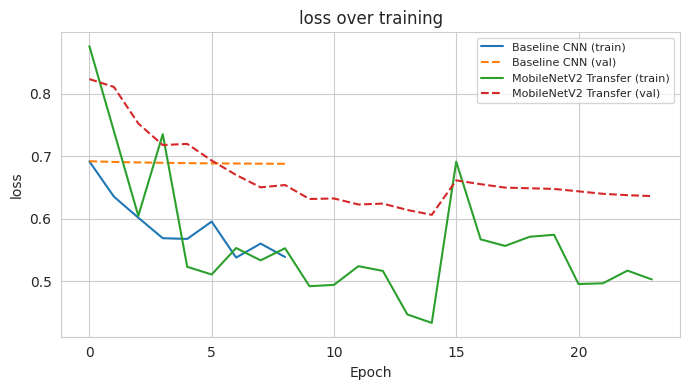

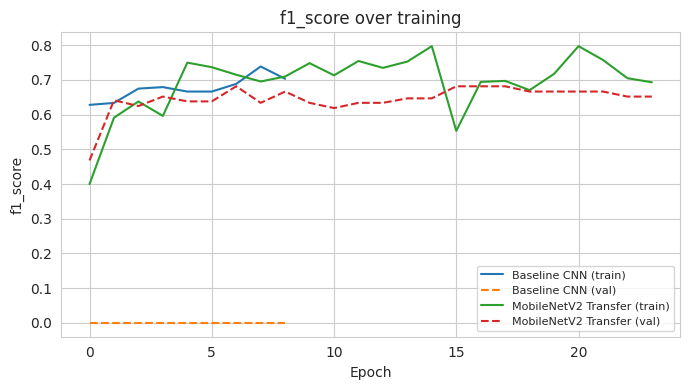

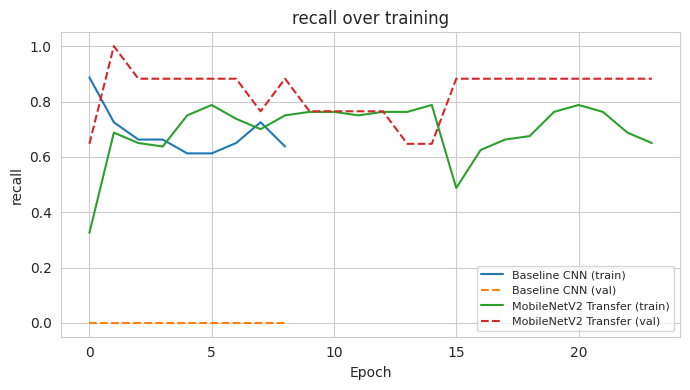

In [28]:
def plot_history(histories, labels, metric):
    fig, ax = plt.subplots(figsize=(7, 4))
    for hist, lab in zip(histories, labels):
        if metric in hist.history:
            ax.plot(hist.history[metric], label=f"{lab} (train)")
        if f"val_{metric}" in hist.history:
            ax.plot(hist.history[f"val_{metric}"], label=f"{lab} (val)", linestyle="--")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(metric)
    ax.set_title(f"{metric} over training")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

# Combine phase 1 + phase 2 history for the transfer model
combined_history = {}
for k in history_phase1.history:
    combined_history[k] = history_phase1.history[k] + history_phase2.history.get(k, [])

class _H:  # small wrapper so plot_history can treat it like a History object
    def __init__(self, d): self.history = d

transfer_history_combined = _H(combined_history)

plot_history([baseline_history, transfer_history_combined],
             ["Baseline CNN", "MobileNetV2 Transfer"], "loss")
plot_history([baseline_history, transfer_history_combined],
             ["Baseline CNN", "MobileNetV2 Transfer"], "f1_score")
plot_history([baseline_history, transfer_history_combined],
             ["Baseline CNN", "MobileNetV2 Transfer"], "recall")


---
## Step 5: Evaluation

Evaluation deliberately centers on **Recall for the Potential Dysgraphia class**, not accuracy —
missing an at-risk child is the cost this tool exists to avoid. Precision, F1, ROC-AUC, and the
confusion matrix are reported alongside it so precision doesn't collapse in the process, and Grad-CAM
confirms the model is keying on handwriting mechanics rather than incidental artifacts.


### 5.1 Test-set evaluation — baseline vs. transfer model

=== Baseline CNN ===
                          precision    recall  f1-score   support

Low Potential Dysgraphia       0.55      1.00      0.71        21
    Potential Dysgraphia       0.00      0.00      0.00        17

                accuracy                           0.55        38
               macro avg       0.28      0.50      0.36        38
            weighted avg       0.31      0.55      0.39        38

ROC-AUC: 0.8123


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/m

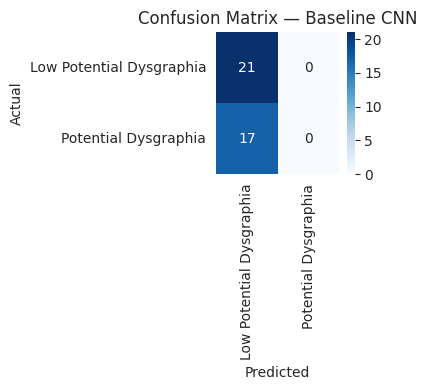

=== MobileNetV2 Transfer ===
                          precision    recall  f1-score   support

Low Potential Dysgraphia       0.75      0.43      0.55        21
    Potential Dysgraphia       0.54      0.82      0.65        17

                accuracy                           0.61        38
               macro avg       0.64      0.63      0.60        38
            weighted avg       0.66      0.61      0.59        38

ROC-AUC: 0.7647


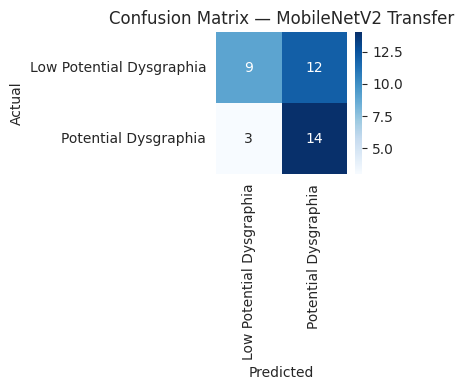

In [29]:
def evaluate_model(model, dataset, df_for_labels, model_name):
    y_true = df_for_labels["label"].values
    y_prob = model.predict(dataset, verbose=0).flatten()
    y_pred = (y_prob >= 0.5).astype(int)

    report = classification_report(y_true, y_pred, target_names=[CLASS_LPD, CLASS_PD],
                                    output_dict=True)
    auc = roc_auc_score(y_true, y_prob)
    f1_pd = f1_score(y_true, y_pred, pos_label=1)

    print(f"=== {model_name} ===")
    print(classification_report(y_true, y_pred, target_names=[CLASS_LPD, CLASS_PD]))
    print(f"ROC-AUC: {auc:.4f}")

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=[CLASS_LPD, CLASS_PD], yticklabels=[CLASS_LPD, CLASS_PD], ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"Confusion Matrix — {model_name}")
    plt.tight_layout()
    plt.show()

    return {
        "model": model_name,
        "recall_PD": report[CLASS_PD]["recall"],
        "precision_PD": report[CLASS_PD]["precision"],
        "f1_PD": f1_pd,
        "roc_auc": auc,
        "accuracy": report["accuracy"],
        "y_true": y_true, "y_prob": y_prob,
    }

baseline_results = evaluate_model(baseline_model, test_ds, test_df, "Baseline CNN")
transfer_results = evaluate_model(transfer_model, test_ds_mnv2, test_df, "MobileNetV2 Transfer")


In [30]:
# Metrics comparison table (deliverable: baseline vs. transfer)
metrics_table = pd.DataFrame([
    {k: v for k, v in baseline_results.items() if k not in ("y_true", "y_prob")},
    {k: v for k, v in transfer_results.items() if k not in ("y_true", "y_prob")},
]).set_index("model").round(4)

metrics_table


,recall_PD,precision_PD,f1_PD,roc_auc,accuracy
model,,,,,
Baseline CNN,0.0000,0.0000,0.0000,0.8123,0.5526
MobileNetV2 Transfer,0.8235,0.5385,0.6512,0.7647,0.6053


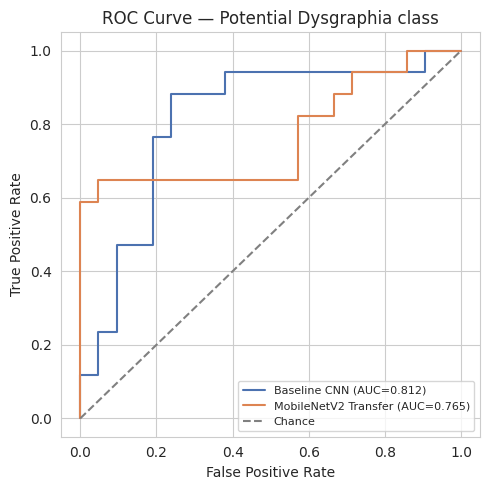

In [31]:
# ROC curves
fig, ax = plt.subplots(figsize=(5, 5))
for res, color in zip([baseline_results, transfer_results], ["#4C72B0", "#DD8452"]):
    fpr, tpr, _ = roc_curve(res["y_true"], res["y_prob"])
    ax.plot(fpr, tpr, label=f"{res['model']} (AUC={res['roc_auc']:.3f})", color=color)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Potential Dysgraphia class")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


### 5.2 Interpretability — Grad-CAM

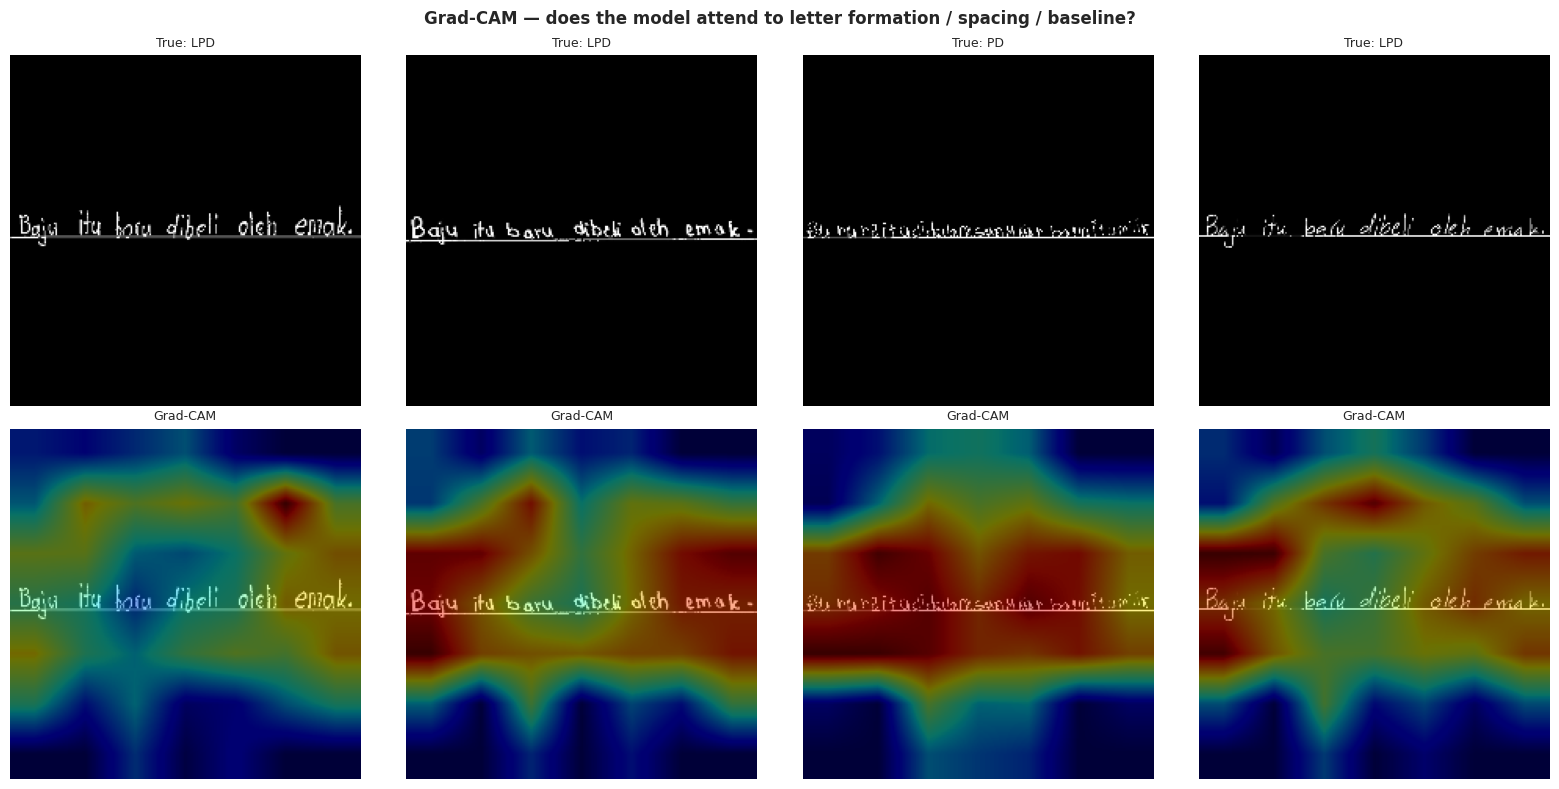

Interpretability check: heat should concentrate on strokes, letter junctions, and baseline regions -- not on page borders, scan artifacts, or empty background. If it doesn't, revisit preprocessing (binarization consistency) or add attention regularization before trusting the model.


In [34]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, container_name=None, pred_index=None):
    if container_name is not None:
        base_model = model.get_layer(container_name)
        conv_layer = base_model.get_layer(last_conv_layer_name)

        # Model that exposes both the conv feature map and the base model's own output
        base_grad_model = keras.Model(base_model.inputs, [conv_layer.output, base_model.output])

        with tf.GradientTape() as tape:
            conv_outputs, base_outputs = base_grad_model(img_array)
            tape.watch(conv_outputs)  # needed since it's an intermediate tensor, not a Variable

            # Manually replay the remaining outer-model layers (everything after the base submodel)
            x = base_outputs
            found_base = False
            for layer in model.layers:
                if layer.name == container_name:
                    found_base = True
                    continue
                if not found_base:
                    continue  # skip the input layer(s) before the base model
                x = layer(x)
            predictions = x

            if pred_index is None:
                pred_index = 0
            class_channel = predictions[:, pred_index]

        grads = tape.gradient(class_channel, conv_outputs)

    else:
        # Conv layer lives directly in the outer model — original approach works fine
        grad_model = keras.Model(model.inputs, [model.get_layer(last_conv_layer_name).output, model.output])
        with tf.GradientTape() as tape:
            conv_outputs, predictions = grad_model(img_array)
            if pred_index is None:
                pred_index = 0
            class_channel = predictions[:, pred_index]
        grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + keras.backend.epsilon())
    return heatmap.numpy()


def find_last_conv_layer(model):
    """Returns (container_layer_name_or_None, conv_layer_name)."""
    for layer in reversed(model.layers):
        if isinstance(layer, layers.Conv2D):
            return None, layer.name
        if hasattr(layer, "layers"):
            for sub in reversed(layer.layers):
                if isinstance(sub, layers.Conv2D):
                    return layer.name, sub.name
    raise ValueError("No Conv2D layer found.")


def show_gradcam(model, dataset, df_for_labels, n=4, three_channel=True):
    container_name, last_conv = find_last_conv_layer(model)
    fig, axes = plt.subplots(2, n, figsize=(4 * n, 8))

    shown = 0
    for imgs, lbls in dataset.take(3):
        for i in range(len(imgs)):
            if shown >= n:
                break
            img_array = imgs[i:i+1]
            heatmap = make_gradcam_heatmap(img_array, model, last_conv, container_name=container_name)
            heatmap_resized = tf.image.resize(heatmap[..., tf.newaxis], IMG_SIZE).numpy().squeeze()

            display_img = imgs[i].numpy()
            if three_channel:
                display_img = (display_img - display_img.min()) / (display_img.max() - display_img.min() + 1e-8)
                display_img = display_img.mean(axis=-1)
            else:
                display_img = display_img.squeeze()

            axes[0, shown].imshow(display_img, cmap="gray")
            axes[0, shown].set_title(f"True: {'PD' if lbls[i]==1 else 'LPD'}", fontsize=9)
            axes[0, shown].axis("off")

            axes[1, shown].imshow(display_img, cmap="gray")
            axes[1, shown].imshow(heatmap_resized, cmap="jet", alpha=0.45)
            axes[1, shown].set_title("Grad-CAM", fontsize=9)
            axes[1, shown].axis("off")

            shown += 1
        if shown >= n:
            break

    plt.suptitle("Grad-CAM — does the model attend to letter formation / spacing / baseline?",
                 fontweight="bold")
    plt.tight_layout()
    plt.show()

show_gradcam(transfer_model, test_ds_mnv2, test_df, n=4, three_channel=True)
print("Interpretability check: heat should concentrate on strokes, letter junctions, and baseline "
      "regions -- not on page borders, scan artifacts, or empty background. If it doesn't, revisit "
      "preprocessing (binarization consistency) or add attention regularization before trusting the model.")

---
## Step 6: Deployment

The deployment phase is out of scope for this notebook's execution, but the modeling artifacts above
are what a deployment step consumes directly:

- **Trained model file (.keras):** `transfer_finetuned_best.keras` (best checkpoint by validation F1),
  saved automatically by `ModelCheckpoint` during Phase 2 fine-tuning.
- **Training logs:** `baseline_history` / `history_phase1` / `history_phase2` objects, plotted above.
- **Metrics table:** `metrics_table`, comparing baseline vs. transfer model on the held-out test set.

Per Business Objective (v), the trained model would be wrapped in a simple web interface (e.g. a
Flask/FastAPI backend serving `transfer_finetuned_best.keras`, or a Streamlit/Gradio front end) that:
1. Accepts a photo or scan of a handwriting sample.
2. Runs the same preprocessing pipeline as Step 3 (grayscale, normalize, aspect-ratio-padded resize).
3. Returns the **Potential Dysgraphia probability**, a plain-language explanation of the interpretable
   indicators, and a Grad-CAM overlay.
4. Displays a clear, prominent disclaimer: this is a **screening and referral aid, not a diagnosis** —
   a positive flag means *"worth getting checked by a professional."*
